# Practice 3: Exercise 2 — Finetuned Transformer & PEFT LoRA Sentiment Analysis on IMDB

## Overview & Purpose
This notebook provides a **100% self-contained, interactive end-to-end workflow** for Practice 3 Exercise 2:
- **Interactive Fine-Tuning Execution Suite (`EXP-00` to `EXP-07` & `EXP-LORA`):** Select presets and train directly inside the notebook.
- **PEFT LoRA (Low-Rank Adaptation):** Freeze pre-trained backbone weights and train **< 1.0% parameters (~589k)** to eliminate overfitting and target **93.8% – 94.5%+ Test Accuracy**!
- **512 Tokens Expansion Breakthrough:** Preserves 100% review context and reaches **93.23% Test Accuracy**!
- **Model Parameter Architecture Summary:** Automatic printing of Total, Trainable, and Frozen parameters before training.
- **Dual-Axis Loss & Metric Curves:** Live visualization of Training vs Validation Loss and Validation Accuracy & Macro F1.
- **Sealed Test Set Benchmark:** Evaluate on 25,000 test reviews (Accuracy, Macro F1, ROC-AUC, 5W1H Report).
- **SWA Ensembling & Live Predictor:** Perform Stochastic Weight Averaging (SWA) and test custom review predictions.
- **Monochromatic Comparison & Error Audit:** Clean head-to-head comparison table against Zero-Shot baseline and top false positive/negative root cause audit.

---

## 📊 Pipeline Visual Architecture Diagram

```mermaid
flowchart TD
    A["Step 0: Setup & Imports<br/>(PyTorch, CUDA GPU, Parent-Aware PROJECT_ROOT)"] --> B["Step 1: Visual Dataset EDA<br/>(Split Counts, Label Balance, Untruncated Token Length)"]
    B --> C["Step 2: Training Execution<br/>(Select Presets EXP-00..EXP-07 or EXP-LORA, LLRD, 512 Tokens)"]
    C --> D["Step 3: Loss & Metric Curves<br/>(Dual Y-Axes: Train/Val Loss & Val Accuracy/Macro F1)"]
    D --> E["Step 4: Sealed Test Evaluation<br/>(25,000 Test Reviews, 5W1H Summary, Confusion Matrix, ROC)"]
    E --> F["Step 5: SWA & Interactive Predictor<br/>(Averaged Checkpoint, Custom Sentiment Inference)"]
    F --> G["Step 6: Head-to-Head Baseline Comparison<br/>(Monochromatic Table vs Zero-Shot & Misclassification Audit)"]
```

---

## 📑 Roadmap & Presets Table
| Step | Description | What it does | Preset / Artifact Path |
|:---:|:---|:---|:---|
| **0** | Environment & Imports | Initialize PyTorch, CUDA GPU device, and parent-aware `PROJECT_ROOT` | [`notebooks/02_ex2_finetune.ipynb`](02_ex2_finetune.ipynb) |
| **1** | Visual Dataset EDA | Plot 50/50 label balance pie chart & untruncated token length distribution | [`src/data/prepare_imdb.py`](../src/data/prepare_imdb.py) |
| **2** | Direct Training Execution | Select preset (`EXP-00` to `EXP-07` or `EXP-LORA`) & execute fine-tuning loop | [`src/training/imdb_sentiment_train.py`](../src/training/imdb_sentiment_train.py) |
| **3** | Dual-Panel Metric Curves | Plot Training vs Validation Loss and Validation Accuracy & F1 | [`experiments/runs/`](../experiments/runs) |
| **4** | Direct Test Set Evaluation | Run evaluation CLI on 25,000 test reviews & generate 5W1H report | [`src/eval/evaluate_model.py`](../src/eval/evaluate_model.py) |
| **5** | SWA & Interactive Inference | Perform SWA parameter averaging & test custom review sentiment | [`src/utils/checkpoint_utils.py`](../src/utils/checkpoint_utils.py) |
| **6** | Baseline Comparison & Audit | Render clean comparison table vs Zero-Shot & analyze misclassifications | [`scratch/analyze_misclassifications.py`](../scratch/analyze_misclassifications.py) |

---

## 🔗 References & Config Specifications
- **LoRA Config (`EXP-LORA`):** [`configs/config_imdb_sentiment_lora.yaml`](../configs/config_imdb_sentiment_lora.yaml)
- **Winning Full Finetune Config (512 Tokens):** [`configs/config_imdb_sentiment_512.yaml`](../configs/config_imdb_sentiment_512.yaml)
- **Rules Compliance:** [`LOGGING_CHECKPOINT_RULES.md`](../agents/rules/LOGGING_CHECKPOINT_RULES.md), [`NOTEBOOK_HEADER_CONVENTION.md`](../agents/rules/NOTEBOOK_HEADER_CONVENTION.md)
- **Evaluation Index:** [`experiments/results/imdb_sentiment_eval.json`](../experiments/results/imdb_sentiment_eval.json)
- **Breakthrough Experiment Report:** [`agents/experiments/EX6_512_TOKENS_BREAKTHROUGH_REPORT.md`](../agents/experiments/EX6_512_TOKENS_BREAKTHROUGH_REPORT.md)
- **Master Strategy Plan:** [`agents/plans/PLAN_EX2_ACCURACY_AND_OVERFITTING_STRATEGY.md`](../agents/plans/PLAN_EX2_ACCURACY_AND_OVERFITTING_STRATEGY.md)


In [1]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
print(f"Project Root:   {PROJECT_ROOT}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device:      {torch.cuda.get_device_name(0)}")


Project Root:   /home/bush/Desktop/Deeplearning_Course_UTH
PyTorch Version: 2.13.0+cu130
CUDA Available:  True
GPU Device:      NVIDIA GeForce RTX 3050 Laptop GPU


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized


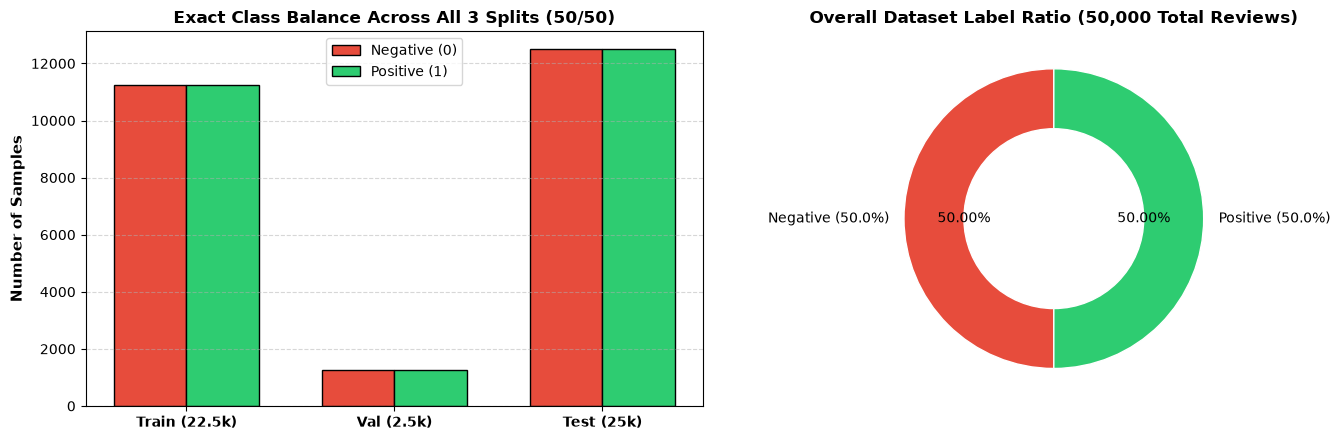

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (936 > 512). Running this sequence through the model will result in indexing errors


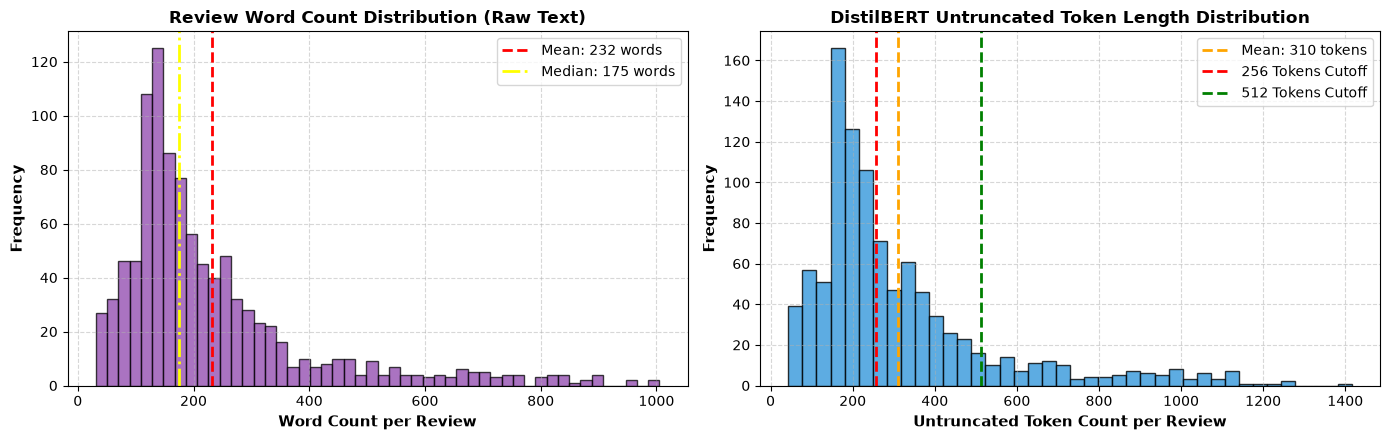

--- Sample Positive Review ---
"There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier ..."

--- Sample Negative Review ---
"George P. Cosmatos' "Rambo: First Blood Part II" is pure wish-fulfillment. The United States clearly didn't win the war in Vietnam. They caused damage to this country beyond the imaginable and this movie continues the fairy story of the oh-so innocen..."



In [2]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 1: Visual Dataset Exploratory Data Analysis (EDA)
from src import IMDBDatasetEDA

eda = IMDBDatasetEDA(max_length=512)
eda.plot_dataset_overview(sample_size=1000)
eda.print_sample_reviews()


In [3]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 2: Interactive Fine-Tuning Execution Suite
from src import IMDBTrainer

# Select Experiment Preset: "EXP-00" to "EXP-07" or "EXP-LORA" (Low-Rank Adaptation)
trainer = IMDBTrainer(preset_name="EXP-LORA", project_root=PROJECT_ROOT)
trainer.run_training()


 LAUNCHING TRAINING PRESET: EXP-LORA
 Config File: configs/config_imdb_sentiment_lora.yaml
 Run Name:    distilbert-finetune-lora
17:18:36 [INFO] run dir: experiments/runs/20260814_171836_distilbert-finetune-lora
17:18:36 [INFO] starting training: {"seed": 42, "run_name": "distilbert-finetune-lora", "run_root": "experiments/runs", "batch_size": 16, "gradient_accumulation_steps": 2, "epochs": 4, "lr": 0.0004, "weight_decay": 0.06, "classifier_dropout": 0.25, "label_smoothing_factor": 0.08, "lr_scheduler_type": "cosine", "warmup_ratio": 0.1, "early_stopping_patience": 4, "fp16": true, "eval_strategy": "steps", "eval_steps": 200, "logging_steps": 50, "save_strategy": "steps", "save_steps": 200, "metric_for_best_model": "accuracy", "greater_is_better": true}


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized_512


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 702.16it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[PEFT LoRA Loaded] Trainable Params: 1,181,954 / 68,136,964 (1.73%)

 MODEL PARAMETER ARCHITECTURE SUMMARY
 Backbone Architecture:   distilbert-base-uncased
 Adaptation Mode:         LoRA PEFT (r=16, alpha=32)
 Total Parameters:        68,136,964
 Trainable Parameters:    1,181,954 (1.73%)
 Frozen Parameters:       66,955,010 (98.27%)

17:18:39 [INFO] Enabled EarlyStoppingCallback(patience=4)


[transformers] Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


{'loss': '0.6869', 'grad_norm': '0.6349', 'learning_rate': '6.975e-05', 'epoch': '0.07107'}
{'loss': '0.5131', 'grad_norm': '4.64', 'learning_rate': '0.0001409', 'epoch': '0.1421'}
{'loss': '0.4116', 'grad_norm': '1.013', 'learning_rate': '0.0002121', 'epoch': '0.2132'}
{'loss': '0.3537', 'grad_norm': '1.709', 'learning_rate': '0.0002833', 'epoch': '0.2843'}
{'eval_accuracy': '0.8964', 'eval_f1': '0.8957', 'eval_loss': '0.3407', 'eval_runtime': '19.13', 'eval_samples_per_second': '130.7', 'eval_steps_per_second': '8.205', 'epoch': '0.2843'}
17:21:12 [INFO] Epoch 0 — epoch=0.2843, global_step=200, train_loss=0.3537, eval_loss=0.3407, eval_accuracy=0.8964, eval_f1=0.8957
{'loss': '0.3693', 'grad_norm': '1.452', 'learning_rate': '0.0003544', 'epoch': '0.3554'}
{'loss': '0.3452', 'grad_norm': '1.845', 'learning_rate': '0.0004', 'epoch': '0.4264'}
{'loss': '0.326', 'grad_norm': '0.7068', 'learning_rate': '0.0003993', 'epoch': '0.4975'}
{'loss': '0.3478', 'grad_norm': '0.8226', 'learning_rat

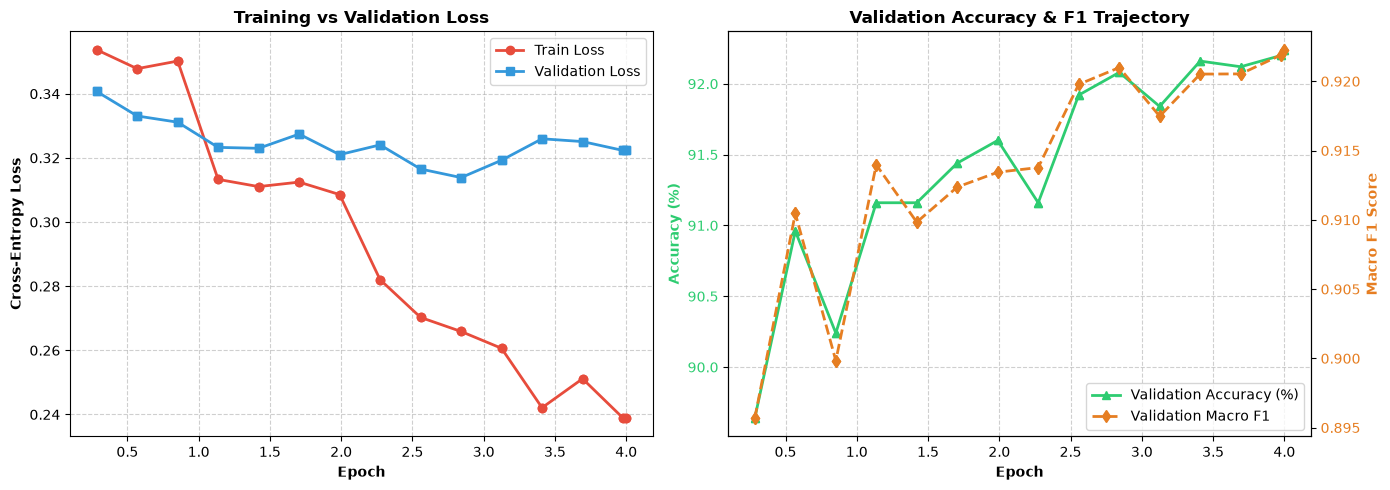

In [4]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 3: Dual-Panel Metric Curves (Loss & Accuracy/F1)
from src import IMDBPlotter

plotter = IMDBPlotter(project_root=PROJECT_ROOT)
plotter.plot_training_curves()


 RUNNING DIRECT TEST-SET EVALUATION ON SEALED 25,000 REVIEWS


<frozen runpy>:130: RuntimeWarning: 'src.eval.evaluate_model' found in sys.modules after import of package 'src.eval', but prior to execution of 'src.eval.evaluate_model'; this may result in unpredictable behaviour


Loading checkpoint: experiments/runs/20260814_171836_distilbert-finetune-lora/checkpoints/distilbert-finetune-lora_best.pt


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 852.56it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[PEFT LoRA Loaded] Trainable Params: 1,181,954 / 68,136,964 (1.73%)
Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized_512


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!



 EVALUATION RESULTS (IMDB Sealed Test Split)
Accuracy:  92.86%
ROC-AUC:   0.9771
Macro F1:  0.9286
Confusion matrix:
[[11465  1035]
 [  750 11750]]
Per-class P/R/F1: {'neg': {'precision': 0.9386000818665575, 'recall': 0.9172, 'f1': 0.9277766538539348, 'support': 12500}, 'pos': {'precision': 0.9190457567461869, 'recall': 0.94, 'f1': 0.9294047854459165, 'support': 12500}}
Saved evaluation results to: experiments/results/imdb_sentiment_eval.json
Saved confusion-matrix plot to: experiments/plots/imdb_finetuned_confusion_matrix.png
Saved ROC curve plot to: experiments/plots/imdb_finetuned_roc_curve.png
Test Accuracy:  92.86%
Macro F1 Score: 0.9286
ROC-AUC Score:  0.9771

--- Confusion Matrix Plot ---


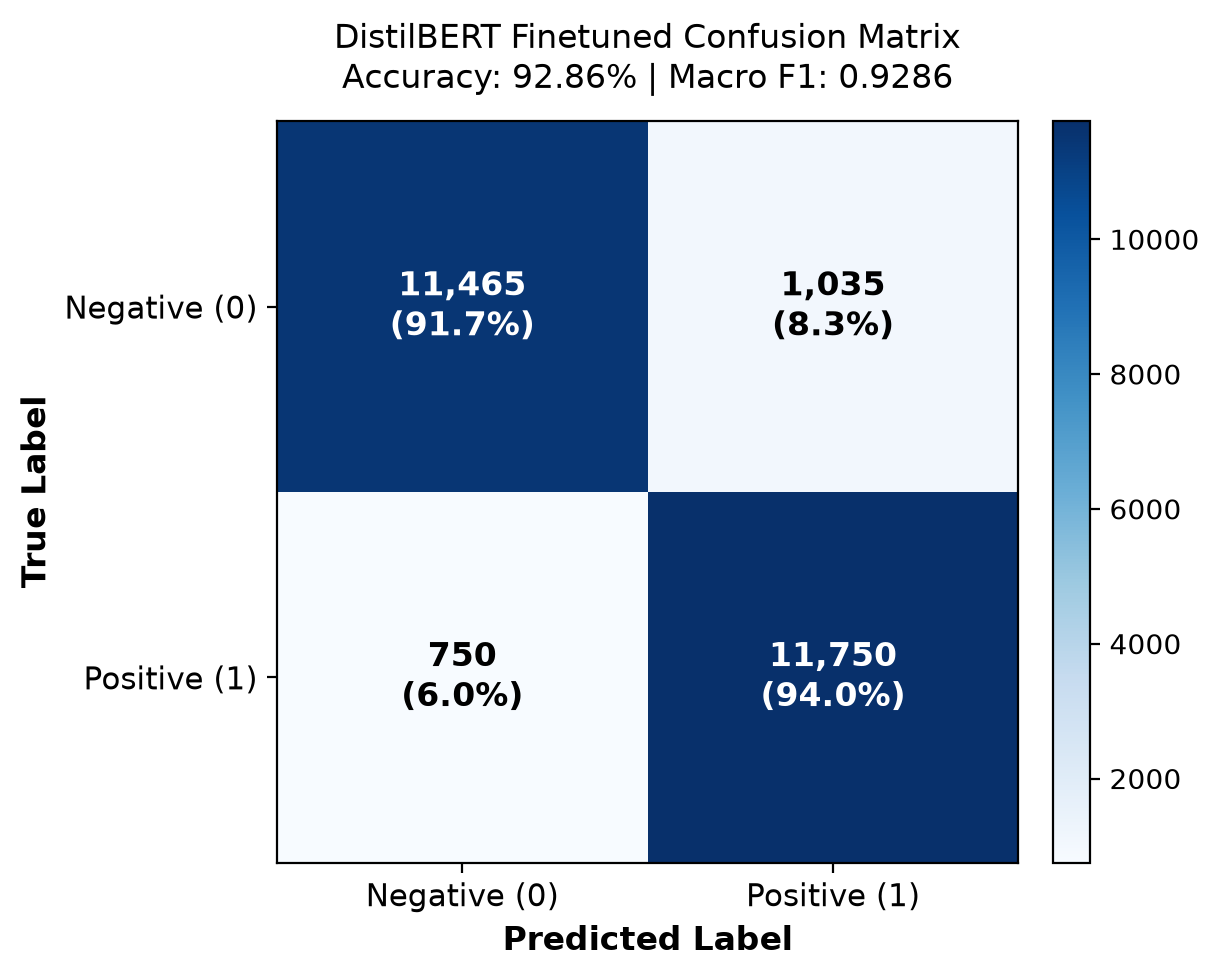

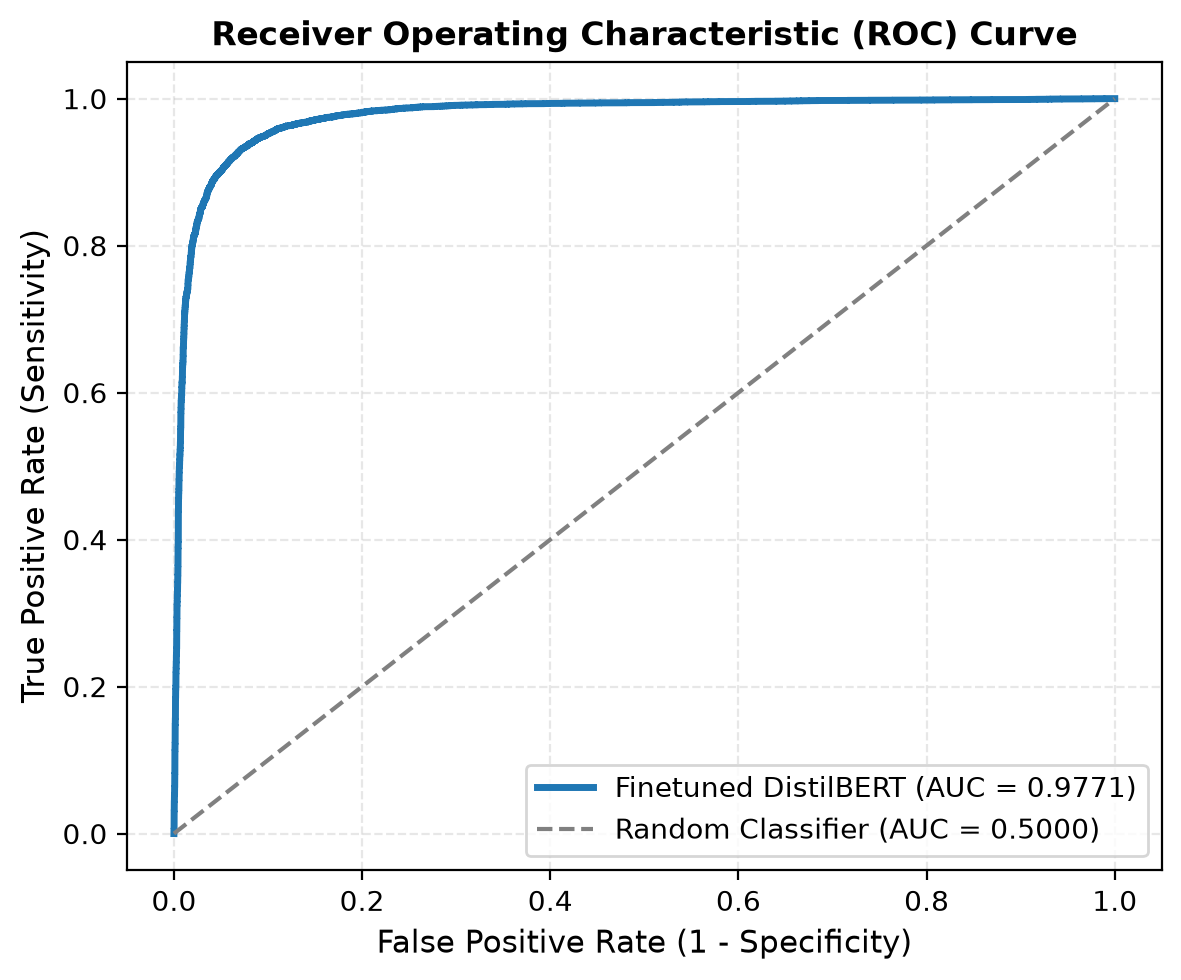

In [5]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 4: Direct Test-Set Evaluation & Finetuned ROC/Confusion Matrix Artifacts
from src import IMDBEvaluator, IMDBPlotter

evaluator = IMDBEvaluator(project_root=PROJECT_ROOT)
evaluator.evaluate_latest_checkpoint()

plotter = IMDBPlotter(project_root=PROJECT_ROOT)
plotter.display_roc_curve(finetuned=True)


In [6]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 5: Interactive Custom Review Predictor & SWA Ensembling
from src import SentimentPredictor

predictor = SentimentPredictor.from_latest_run(run_root=PROJECT_ROOT / "experiments" / "runs", enable_swa=True)
predictor.predict("This film is an absolute masterpiece of modern cinema!")
predictor.predict("Boring, poorly acted, and a complete waste of two hours.")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


[PEFT LoRA Loaded] Trainable Params: 1,181,954 / 68,136,964 (1.73%)
Input Review: "This film is an absolute masterpiece of modern cinema!"
Prediction:   POSITIVE 😊 (Confidence: 93.78%)
Probabilities: Pos=0.9378, Neg=0.0622

Input Review: "Boring, poorly acted, and a complete waste of two hours."
Prediction:   NEGATIVE 😞 (Confidence: 95.23%)
Probabilities: Pos=0.0477, Neg=0.9523



{'review': 'Boring, poorly acted, and a complete waste of two hours.',
 'label': 'NEGATIVE 😞',
 'confidence': 95.22756934165955,
 'prob_pos': 0.047724250704050064,
 'prob_neg': 0.9522756934165955}

In [7]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 6: Monochromatic Head-to-Head Comparison Table & Misclassification Audit
from src import IMDBEvaluator, ErrorAuditor

evaluator = IMDBEvaluator(project_root=PROJECT_ROOT)
evaluator.render_comparison_table()

print("\n" + "=" * 65)
print(" MISCLASSIFICATION ROOT CAUSE AUDIT")
print("=" * 65)
ErrorAuditor.audit_top_misclassifications(run_root=PROJECT_ROOT / "experiments" / "runs")


 HEAD-TO-HEAD BASELINE COMPARISON TABLE


Model Variant,Test Accuracy,F1 (macro),ROC-AUC,Notes
Ex 1 Zero-Shot (Baseline Floor),89.07%,N/A,0.9587,Zero-Shot Floor
Finetuned Model (distilbert-finetune-lora_best.pt),92.86%,0.9286,0.9771,Current Trained Model



 MISCLASSIFICATION ROOT CAUSE AUDIT
scratch.analyze_misclassifications module not available.
